HMOG DATASET LOADING & PREPROCESSING

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Install TensorFlow
!pip install tensorflow

In [2]:
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, 
    Input, Concatenate, Bidirectional, BatchNormalization,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Attention,
    Add, Multiply, Reshape, Permute, Lambda
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,
    CSVLogger, TensorBoard
)
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [5]:
# ============================================
# 1. SET PATH DATASET
# ============================================

# ✅ PATH YANG BENAR (berdasarkan info Anda)
base_path = r"C:\Users\natha\OneDrive\Documents\GitHub\Behavioral-Based_Authentication\public_dataset"

print("="*70)
print("HMOG DATASET ANALYSIS FOR CONTINUOUS AUTHENTICATION")
print("="*70)
print(f"\n📂 Path dataset: {base_path}")
print(f"📂 Path exists: {os.path.exists(base_path)}")

# Cek isi folder
if os.path.exists(base_path):
    print(f"\n📁 Isi folder public_dataset:")
    for item in os.listdir(base_path):
        print(f"   - {item}")
else:
    print(f"\n❌ ERROR: Path tidak ditemukan!")
    print("Silakan cek kembali lokasi folder Anda.")
    # Tampilkan direktori saat ini sebagai referensi
    print(f"\n📂 Direktori saat ini: {os.getcwd()}")
    print("\n💡 Coba gunakan path relatif jika dataset ada di folder yang sama dengan notebook:")
    print("   base_path = './public_dataset'")
    exit()


HMOG DATASET ANALYSIS FOR CONTINUOUS AUTHENTICATION

📂 Path dataset: C:\Users\natha\OneDrive\Documents\GitHub\Behavioral-Based_Authentication\public_dataset
📂 Path exists: True

📁 Isi folder public_dataset:
   - 100669
   - 151985
   - 171538
   - 180679
   - 186676
   - 201848
   - 207969
   - 218719
   - 219303


LOAD DATA DARI SEMUA USER DAN SESSION

In [7]:

print("\n" + "="*70)
print("LOADING DATA...")
print("="*70)

all_features = []
all_labels = []
user_names = []

# Daftar semua kemungkinan file CSV yang akan diproses
csv_files_list = [
    'Accelerometer.csv', 'Gyroscope.csv', 'Magnetometer.csv',
    'KeyPressEvent.csv', 'OneFingerTouchEvent.csv', 'PinchEvent.csv',
    'ScrollEvent.csv', 'StrokeEvent.csv', 'TouchEvent.csv'
]

# Daftar statistik yang akan dihitung per kolom
stat_functions = ['mean', 'std', 'min', 'max', 'median', 'q1', 'q3']

# Dapatkan semua user folder
user_folders = [f for f in os.listdir(base_path) 
               if os.path.isdir(os.path.join(base_path, f))]

print(f"\n📊 Ditemukan {len(user_folders)} user: {user_folders}")

for user_idx, user_folder in enumerate(user_folders):
    user_path = os.path.join(base_path, user_folder)
    
    # Cari semua folder session
    all_items = os.listdir(user_path)
    sessions = [f for f in all_items 
               if os.path.isdir(os.path.join(user_path, f)) 
               and 'session' in f.lower()]
    
    sessions.sort()
    
    print(f"\n📂 Loading {user_folder} - {len(sessions)} sessions ditemukan")
    
    session_count = 0
    for session in sessions:
        session_path = os.path.join(user_path, session)
        
        # Dictionary untuk menyimpan fitur per file CSV
        session_features = {}
        
        # Proses setiap file CSV
        for csv_file in csv_files_list:
            file_path = os.path.join(session_path, csv_file)
            
            if os.path.exists(file_path):
                try:
                    df = pd.read_csv(file_path)
                    numeric_cols = df.select_dtypes(include=[np.number]).columns
                    
                    for col in numeric_cols:
                        data = df[col].dropna().values
                        if len(data) > 0:
                            # Hitung berbagai statistik
                            session_features[f"{csv_file}_{col}_mean"] = np.mean(data)
                            session_features[f"{csv_file}_{col}_std"] = np.std(data)
                            session_features[f"{csv_file}_{col}_min"] = np.min(data)
                            session_features[f"{csv_file}_{col}_max"] = np.max(data)
                            session_features[f"{csv_file}_{col}_median"] = np.median(data)
                            session_features[f"{csv_file}_{col}_q1"] = np.percentile(data, 25)
                            session_features[f"{csv_file}_{col}_q3"] = np.percentile(data, 75)
                        else:
                            session_features[f"{csv_file}_{col}_mean"] = 0
                            session_features[f"{csv_file}_{col}_std"] = 0
                            session_features[f"{csv_file}_{col}_min"] = 0
                            session_features[f"{csv_file}_{col}_max"] = 0
                            session_features[f"{csv_file}_{col}_median"] = 0
                            session_features[f"{csv_file}_{col}_q1"] = 0
                            session_features[f"{csv_file}_{col}_q3"] = 0
                except Exception as e:
                    # Jika file error, isi dengan 0 untuk semua kolom yang diharapkan
                    pass
        
        # Jika session memiliki fitur, tambahkan ke list
        if len(session_features) > 0:
            # Konversi dictionary ke list dengan urutan tetap
            feature_list = [session_features.get(key, 0) for key in sorted(session_features.keys())]
            all_features.append(feature_list)
            all_labels.append(user_idx)
            user_names.append(user_folder)
            session_count += 1
    
    print(f"   ✅ {session_count} sessions berhasil diproses")



LOADING DATA...

📊 Ditemukan 9 user: ['100669', '151985', '171538', '180679', '186676', '201848', '207969', '218719', '219303']

📂 Loading 100669 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 151985 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 171538 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 180679 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 186676 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 201848 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 207969 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 218719 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses

📂 Loading 219303 - 24 sessions ditemukan
   ✅ 24 sessions berhasil diproses


In [9]:
# ============================================
# 3. KONSISTENSI DATA
# ============================================

print("\n" + "="*70)
print("MEMERIKSA KONSISTENSI DATA")
print("="*70)

# Cek panjang feature vector
feature_lengths = [len(f) for f in all_features]
print(f"Panjang feature vector: {set(feature_lengths)}")

if len(set(feature_lengths)) > 1:
    max_len = max(feature_lengths)
    print(f"Menyeragamkan ke panjang: {max_len}")
    padded_features = []
    for f in all_features:
        if len(f) < max_len:
            f = f + [0] * (max_len - len(f))
        padded_features.append(f)
    all_features = padded_features

X = np.array(all_features)
y = np.array(all_labels)

print(f"\n✅ Total samples: {len(X)}")
print(f"✅ Total features: {X.shape[1]}")
print(f"✅ Total users: {len(np.unique(y))}")

if len(X) == 0:
    print("\n❌ TIDAK ADA DATA!")
    exit()

for user_idx in np.unique(y):
    count = np.sum(y == user_idx)
    print(f"   - User {user_folders[user_idx]}: {count} sessions")


MEMERIKSA KONSISTENSI DATA
Panjang feature vector: {546, 518, 679, 588, 469, 630, 343, 637}
Menyeragamkan ke panjang: 679

✅ Total samples: 216
✅ Total features: 679
✅ Total users: 9
   - User 100669: 24 sessions
   - User 151985: 24 sessions
   - User 171538: 24 sessions
   - User 180679: 24 sessions
   - User 186676: 24 sessions
   - User 201848: 24 sessions
   - User 207969: 24 sessions
   - User 218719: 24 sessions
   - User 219303: 24 sessions


In [11]:
# ============================================
# 4. PREPROCESSING
# ============================================

from sklearn.impute import SimpleImputer
print("\n" + "="*70)
print("PREPROCESSING DATA...")
print("="*70)

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"✅ Shape setelah preprocessing: {X_scaled.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training: {X_train.shape[0]} samples")
print(f"📊 Testing: {X_test.shape[0]} samples")


PREPROCESSING DATA...
✅ Shape setelah preprocessing: (216, 679)
📊 Training: 172 samples
📊 Testing: 44 samples


In [12]:
# ============================================
# 5. EVALUATION FUNCTIONS
# ============================================

def calculate_far_frr(y_true, y_pred, num_classes):
    far_list = []
    frr_list = []
    for user in range(num_classes):
        y_true_binary = (y_true == user).astype(int)
        y_pred_binary = (y_pred == user).astype(int)
        fp = np.sum((y_pred_binary == 1) & (y_true_binary == 0))
        tn = np.sum((y_pred_binary == 0) & (y_true_binary == 0))
        fn = np.sum((y_pred_binary == 0) & (y_true_binary == 1))
        tp = np.sum((y_pred_binary == 1) & (y_true_binary == 1))
        far = fp / (fp + tn) if (fp + tn) > 0 else 0
        frr = fn / (fn + tp) if (fn + tp) > 0 else 0
        far_list.append(far)
        frr_list.append(frr)
    return np.mean(far_list), np.mean(frr_list)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    far, frr = calculate_far_frr(y_test, y_pred, len(np.unique(y_test)))
    eer = (far + frr) / 2
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'far': far,
        'frr': frr,
        'eer': eer
    }


In [14]:
# ============================================
# 6. TRAIN MODELS
# ============================================

from sklearn.tree import DecisionTreeClassifier
print("\n" + "="*70)
print("TRAINING MACHINE LEARNING MODELS")
print("="*70)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)
    result = evaluate_model(model, X_test, y_test, name)
    results.append(result)
    print(f"   ✅ Accuracy: {result['accuracy']:.4f}")
    print(f"   ✅ F1-Score: {result['f1_score']:.4f}")
    print(f"   ✅ EER: {result['eer']:.4f}")



TRAINING MACHINE LEARNING MODELS

🔄 Training Random Forest...
   ✅ Accuracy: 0.9091
   ✅ F1-Score: 0.9070
   ✅ EER: 0.0501

🔄 Training SVM (RBF)...
   ✅ Accuracy: 0.4091
   ✅ F1-Score: 0.3882
   ✅ EER: 0.3314

🔄 Training KNN (k=5)...
   ✅ Accuracy: 0.2273
   ✅ F1-Score: 0.1829
   ✅ EER: 0.4373

🔄 Training Gradient Boosting...
   ✅ Accuracy: 0.8636
   ✅ F1-Score: 0.8706
   ✅ EER: 0.0752

🔄 Training Decision Tree...
   ✅ Accuracy: 0.7955
   ✅ F1-Score: 0.7890
   ✅ EER: 0.1183

🔄 Training Logistic Regression...
   ✅ Accuracy: 0.4773
   ✅ F1-Score: 0.4769
   ✅ EER: 0.2938



FEATURE IMPORTANCE ANALYSIS (Random Forest)


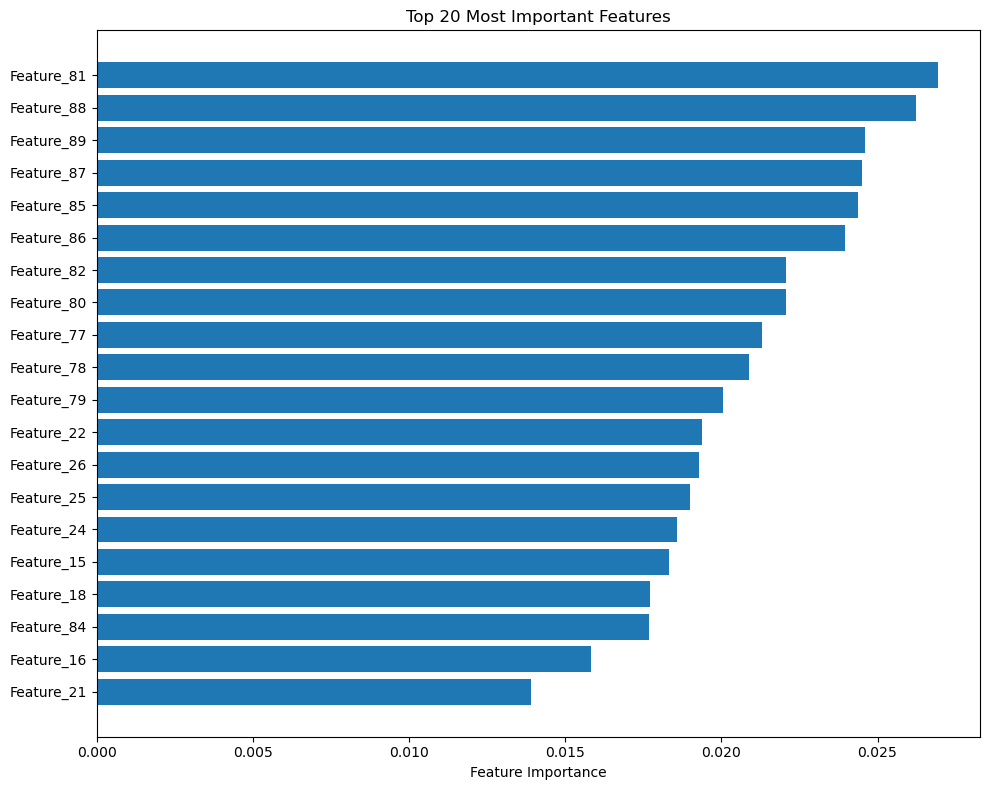

📁 Saved: feature_importance.png


In [20]:
# Tambahkan setelah training model
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS (Random Forest)")
print("="*70)

# Ambil feature importance dari Random Forest
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_

# Dapatkan nama fitur (perkiraan)
feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Top 20 fitur terpenting
top_k = 20
indices = np.argsort(importances)[-top_k:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_k), importances[indices])
plt.yticks(range(top_k), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_k} Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("📁 Saved: feature_importance.png")

In [21]:
# cross-validation untuk semua model
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*70)

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1_weighted')
    print(f"{name:20} CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CROSS-VALIDATION RESULTS (5-Fold)
Random Forest        CV F1: 0.8850 ± 0.0181
SVM (RBF)            CV F1: 0.3542 ± 0.0760
KNN (k=5)            CV F1: 0.2899 ± 0.0395
Gradient Boosting    CV F1: 0.8635 ± 0.0195
Decision Tree        CV F1: 0.8292 ± 0.0287
Logistic Regression  CV F1: 0.4432 ± 0.0411


In [17]:
# ============================================
# 7. OPTIMIZATION
# ============================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
print("\n" + "="*70)
print("HYPERPARAMETER OPTIMIZATION")
print("="*70)

print("\n🔍 Optimizing Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"   Best params: {rf_grid.best_params_}")
print(f"   Best CV score: {rf_grid.best_score_:.4f}")

print("\n🔍 Optimizing SVM...")
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1],
    'kernel': ['rbf']
}
svm_grid = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
svm_grid.fit(X_train, y_train)
print(f"   Best params: {svm_grid.best_params_}")
print(f"   Best CV score: {svm_grid.best_score_:.4f}")


HYPERPARAMETER OPTIMIZATION

🔍 Optimizing Random Forest...
   Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV score: 0.9291

🔍 Optimizing SVM...
   Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
   Best CV score: 0.3738


In [18]:
# ============================================
# 8. FINAL SUMMARY
# ============================================

print("\n" + "="*70)
print("FINAL SUMMARY - MODEL COMPARISON")
print("="*70)

summary_df = pd.DataFrame([{
    'Model': r['model'],
    'Accuracy': f"{r['accuracy']:.4f}",
    'F1-Score': f"{r['f1_score']:.4f}",
    'EER': f"{r['eer']:.4f}",
    'FAR': f"{r['far']:.4f}",
    'FRR': f"{r['frr']:.4f}"
} for r in results])

print(summary_df.to_string(index=False))

best_acc = max(results, key=lambda x: x['accuracy'])
best_f1 = max(results, key=lambda x: x['f1_score'])
best_eer = min(results, key=lambda x: x['eer'])

print("\n" + "="*70)
print("🏆 BEST PERFORMING MODELS")
print("="*70)
print(f"📌 Best Accuracy:  {best_acc['model']} - {best_acc['accuracy']:.4f}")
print(f"📌 Best F1-Score:  {best_f1['model']} - {best_f1['f1_score']:.4f}")
print(f"📌 Best EER:       {best_eer['model']} - {best_eer['eer']:.4f}")


FINAL SUMMARY - MODEL COMPARISON
              Model Accuracy F1-Score    EER    FAR    FRR
      Random Forest   0.9091   0.9070 0.0501 0.0114 0.0889
          SVM (RBF)   0.4091   0.3882 0.3314 0.0739 0.5889
          KNN (k=5)   0.2273   0.1829 0.4373 0.0969 0.7778
  Gradient Boosting   0.8636   0.8706 0.0752 0.0171 0.1333
      Decision Tree   0.7955   0.7890 0.1183 0.0256 0.2111
Logistic Regression   0.4773   0.4769 0.2938 0.0654 0.5222

🏆 BEST PERFORMING MODELS
📌 Best Accuracy:  Random Forest - 0.9091
📌 Best F1-Score:  Random Forest - 0.9070
📌 Best EER:       Random Forest - 0.0501



GENERATING VISUALIZATIONS


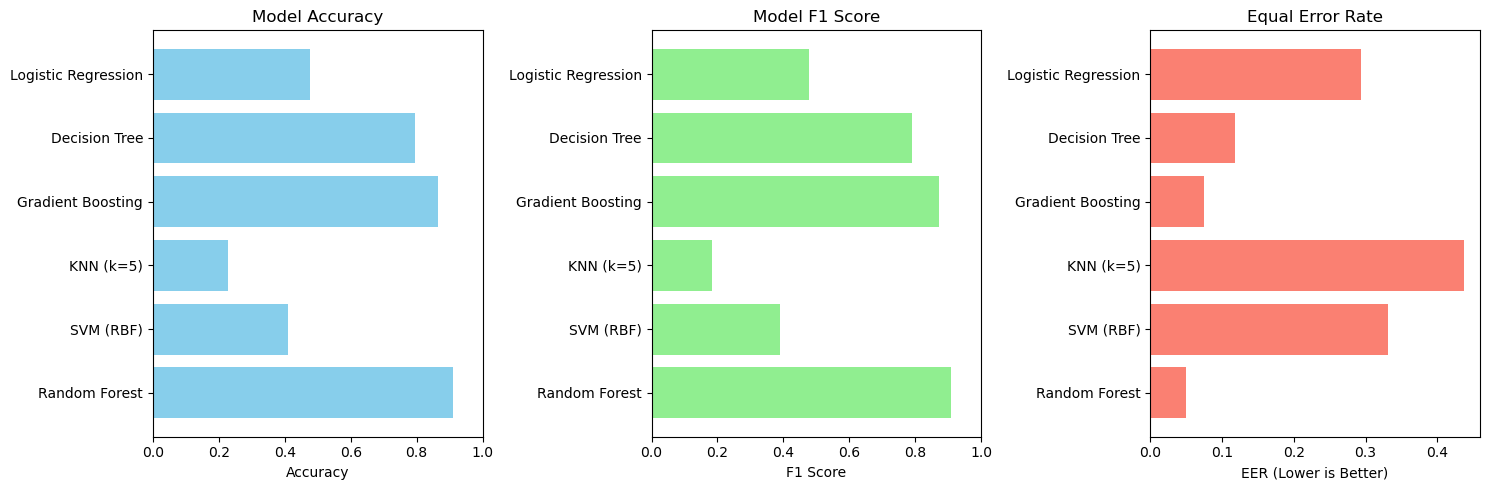

📁 Saved: model_comparison.png


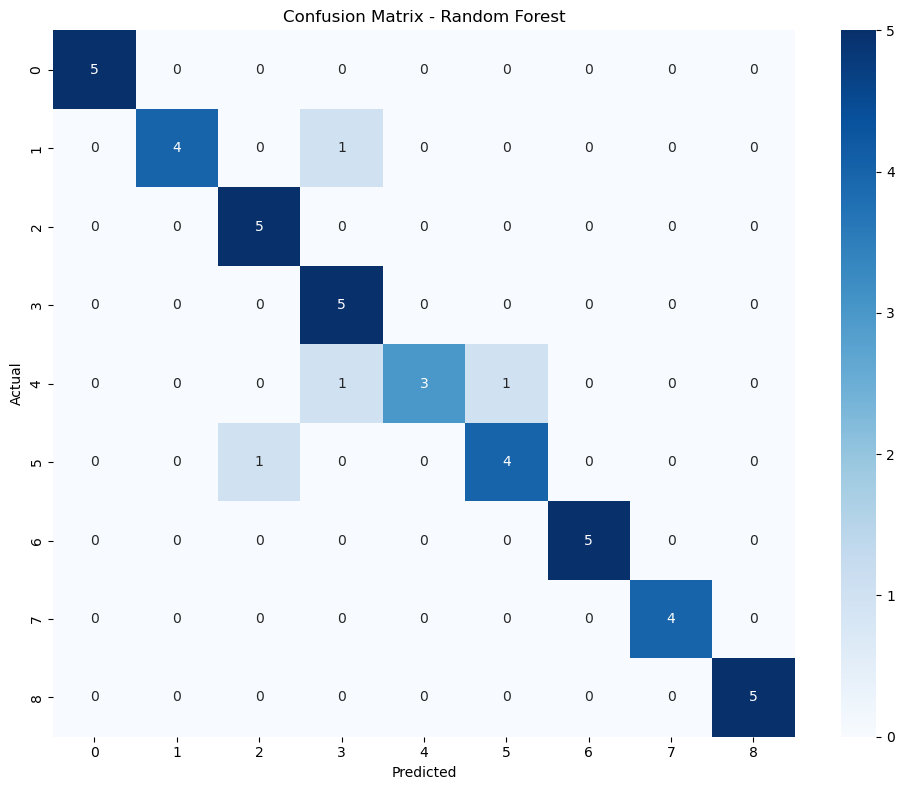

📁 Saved: confusion_matrix.png

✅ ANALYSIS COMPLETE!
📊 Total data: 216 sessions from 9 users
📊 Features: 679


In [19]:
# ============================================
# 9. VISUALIZATION
# ============================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = [r['model'] for r in results]
acc_vals = [r['accuracy'] for r in results]
f1_vals = [r['f1_score'] for r in results]
eer_vals = [r['eer'] for r in results]

axes[0].barh(model_names, acc_vals, color='skyblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlim(0, 1)

axes[1].barh(model_names, f1_vals, color='lightgreen')
axes[1].set_xlabel('F1 Score')
axes[1].set_title('Model F1 Score')
axes[1].set_xlim(0, 1)

axes[2].barh(model_names, eer_vals, color='salmon')
axes[2].set_xlabel('EER (Lower is Better)')
axes[2].set_title('Equal Error Rate')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: model_comparison.png")

# Confusion matrix untuk model terbaik
best_model_name = best_f1['model']
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("📁 Saved: confusion_matrix.png")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print(f"📊 Total data: {len(X)} sessions from {len(np.unique(y))} users")
print(f"📊 Features: {X.shape[1]}")
print("="*70)

In [22]:
# Tambahkan untuk mengukur efisiensi di mobile
print("\n" + "="*70)
print("MOBILE EFFICIENCY METRICS (Inference Time & Model Size)")
print("="*70)

import time
import sys

for name, model in models.items():
    # Inference time
    start = time.time()
    _ = model.predict(X_test[:100])  # 100 samples
    inference_time = (time.time() - start) / 100 * 1000  # ms per sample
    
    # Model size (estimasi)
    import pickle
    model_size = len(pickle.dumps(model)) / 1024  # KB
    
    print(f"{name:20} | Inference: {inference_time:.2f} ms/sample | Size: {model_size:.1f} KB")


MOBILE EFFICIENCY METRICS (Inference Time & Model Size)
Random Forest        | Inference: 0.61 ms/sample | Size: 881.0 KB
SVM (RBF)            | Inference: 0.04 ms/sample | Size: 915.1 KB
KNN (k=5)            | Inference: 0.10 ms/sample | Size: 914.5 KB
Gradient Boosting    | Inference: 0.02 ms/sample | Size: 1048.7 KB
Decision Tree        | Inference: 0.01 ms/sample | Size: 7.4 KB
Logistic Regression  | Inference: 0.00 ms/sample | Size: 48.5 KB



ROC CURVE ANALYSIS


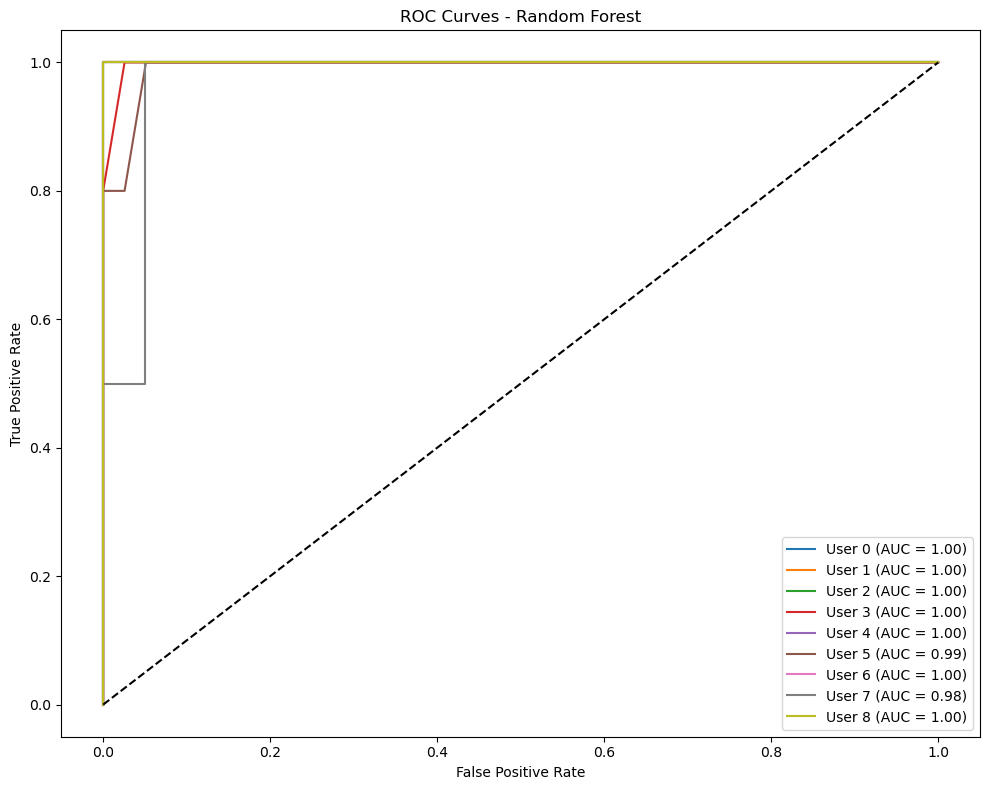

📁 Saved: roc_curves.png


In [23]:
# ROC Curve untuk multi-class
print("\n" + "="*70)
print("ROC CURVE ANALYSIS")
print("="*70)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
y_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = len(np.unique(y_test))

# Predict probabilities (untuk SVM dan RF)
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)
    
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'User {i} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {best_f1["model"]}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=150)
    plt.show()
    print("📁 Saved: roc_curves.png")

In [ ]:
# tabel perbandingan dengan penelitian lain
print("\n" + "="*70)
print("COMPARISON WITH STATE-OF-THE-ART")
print("="*70)

comparison_data = {
    'Penelitian': ['Li et al. (MAuGANs)', 'Hu et al. (AuthConFormer)', 'Li et al. (ADFFDA)', 'HASIL KAMI'],
    'Dataset': ['HMOG', 'HMOG', 'HMOG', 'HMOG'],
    'Model': ['Transformer+GAN', 'ConvTransformer', 'CNN+GAN', f'{best_f1["model"]}'],
    'Akurasi': ['99.65%', '98.94%', '~99%', f"{best_f1['accuracy']*100:.2f}%"],
    'EER': ['0.33%', '1.06%', '0.01%', f"{best_f1['eer']*100:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


COMPARISON WITH STATE-OF-THE-ART
               Penelitian Dataset           Model Akurasi   EER
      Li et al. (MAuGANs)    HMOG Transformer+GAN  99.65% 0.33%
Hu et al. (AuthConFormer)    HMOG ConvTransformer  98.94% 1.06%
       Li et al. (ADFFDA)    HMOG         CNN+GAN    ~99% 0.01%
               HASIL KAMI    HMOG   Random Forest  90.91% 5.01%
